## SETUP

In [1]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_from_pretrained
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

2025-09-21 12:31:22.228576: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 12:31:22.378617: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 12:31:23.003061: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-09-21 12:31:23.003151: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_pretrained.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## MODEL STARTING POINT

In [8]:
from tensorflow.keras.applications import ResNet50V2

# Build backbone from pretrained model
new_cfg = model_cfg["base_model_args"].copy()
backbone = ResNet50V2(**model_cfg["base_model_args"])

# Build model from spec
model = build_from_pretrained(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

2025-09-21 12:31:24.727118: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 12:31:24.843174: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:81:00.0, compute capability: 8.9


Model: "pretrained"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 transition_layer (GlobalAve  (None, 2048)             0         
 ragePooling2D)                                                  
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0

## MODEL EXPLORATION

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [ ]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [ ]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("resnet50v2")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 09:11:55.711032: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 09:11:55.774890: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 09:11:55.802381: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 09:11:55.802423: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 09:11:55.834726: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 09:11:55.834842: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 09:11:55.858718: I tensorflow/stream_executor/cuda/c

323/323 [==============================] - 18s 44ms/step - loss: 6.4371 - auc: 0.5295 - binary_accuracy: 0.5305 - precision: 0.4378 - recall: 0.4869 - val_loss: 5.4207 - val_auc: 0.6945 - val_binary_accuracy: 0.6405 - val_precision: 0.5974 - val_recall: 0.3898 - lr: 1.0000e-04
Epoch 2/80
323/323 [==============================] - 13s 38ms/step - loss: 5.1953 - auc: 0.5368 - binary_accuracy: 0.5352 - precision: 0.4419 - recall: 0.4821 - val_loss: 4.6304 - val_auc: 0.6903 - val_binary_accuracy: 0.6597 - val_precision: 0.6414 - val_recall: 0.3941 - lr: 1.0000e-04
Epoch 3/80
323/323 [==============================] - 13s 37ms/step - loss: 4.5099 - auc: 0.5357 - binary_accuracy: 0.5347 - precision: 0.4397 - recall: 0.4662 - val_loss: 4.0636 - val_auc: 0.7142 - val_binary_accuracy: 0.6702 - val_precision: 0.6741 - val_recall: 0.3856 - lr: 1.0000e-04
Epoch 4/80
323/323 [==============================] - 14s 39ms/step - loss: 3.9894 - auc: 0.5353 - binary_accuracy: 0.5369 - precision: 0.4396 -

In [13]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


323/323 [==============================] - 15s 40ms/step - loss: 0.6280 - auc: 0.7511 - binary_accuracy: 0.6911 - precision: 0.6207 - recall: 0.6460 - val_loss: 0.6766 - val_auc: 0.7611 - val_binary_accuracy: 0.7173 - val_precision: 0.6457 - val_recall: 0.6949 - lr: 1.0000e-05
Epoch 2/80
323/323 [==============================] - 13s 37ms/step - loss: 0.6230 - auc: 0.7619 - binary_accuracy: 0.7017 - precision: 0.6419 - recall: 0.6263 - val_loss: 0.6615 - val_auc: 0.7590 - val_binary_accuracy: 0.7051 - val_precision: 0.6324 - val_recall: 0.6780 - lr: 1.0000e-05
Epoch 3/80
323/323 [==============================] - 16s 40ms/step - loss: 0.6135 - auc: 0.7796 - binary_accuracy: 0.7213 - precision: 0.6713 - recall: 0.6355 - val_loss: 0.6544 - val_auc: 0.7568 - val_binary_accuracy: 0.6981 - val_precision: 0.6189 - val_recall: 0.6949 - lr: 1.0000e-05
Epoch 4/80
323/323 [==============================] - 15s 41ms/step - loss: 0.6160 - auc: 0.7707 - binary_accuracy: 0.7121 - precision: 0.6588 -

In [14]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


323/323 [==============================] - 15s 40ms/step - loss: 0.5839 - auc: 0.8240 - binary_accuracy: 0.7573 - precision: 0.6961 - recall: 0.7306 - val_loss: 0.6652 - val_auc: 0.7498 - val_binary_accuracy: 0.6841 - val_precision: 0.6015 - val_recall: 0.6907 - lr: 3.2768e-06
Epoch 2/80
323/323 [==============================] - 14s 40ms/step - loss: 0.5796 - auc: 0.8245 - binary_accuracy: 0.7570 - precision: 0.6968 - recall: 0.7272 - val_loss: 0.6624 - val_auc: 0.7525 - val_binary_accuracy: 0.6841 - val_precision: 0.6022 - val_recall: 0.6864 - lr: 3.2768e-06
Epoch 3/80
323/323 [==============================] - 13s 38ms/step - loss: 0.5850 - auc: 0.8162 - binary_accuracy: 0.7511 - precision: 0.6980 - recall: 0.6990 - val_loss: 0.6599 - val_auc: 0.7519 - val_binary_accuracy: 0.6894 - val_precision: 0.6082 - val_recall: 0.6907 - lr: 3.2768e-06
Epoch 4/80
323/323 [==============================] - 14s 37ms/step - loss: 0.5770 - auc: 0.8282 - binary_accuracy: 0.7609 - precision: 0.7024 -

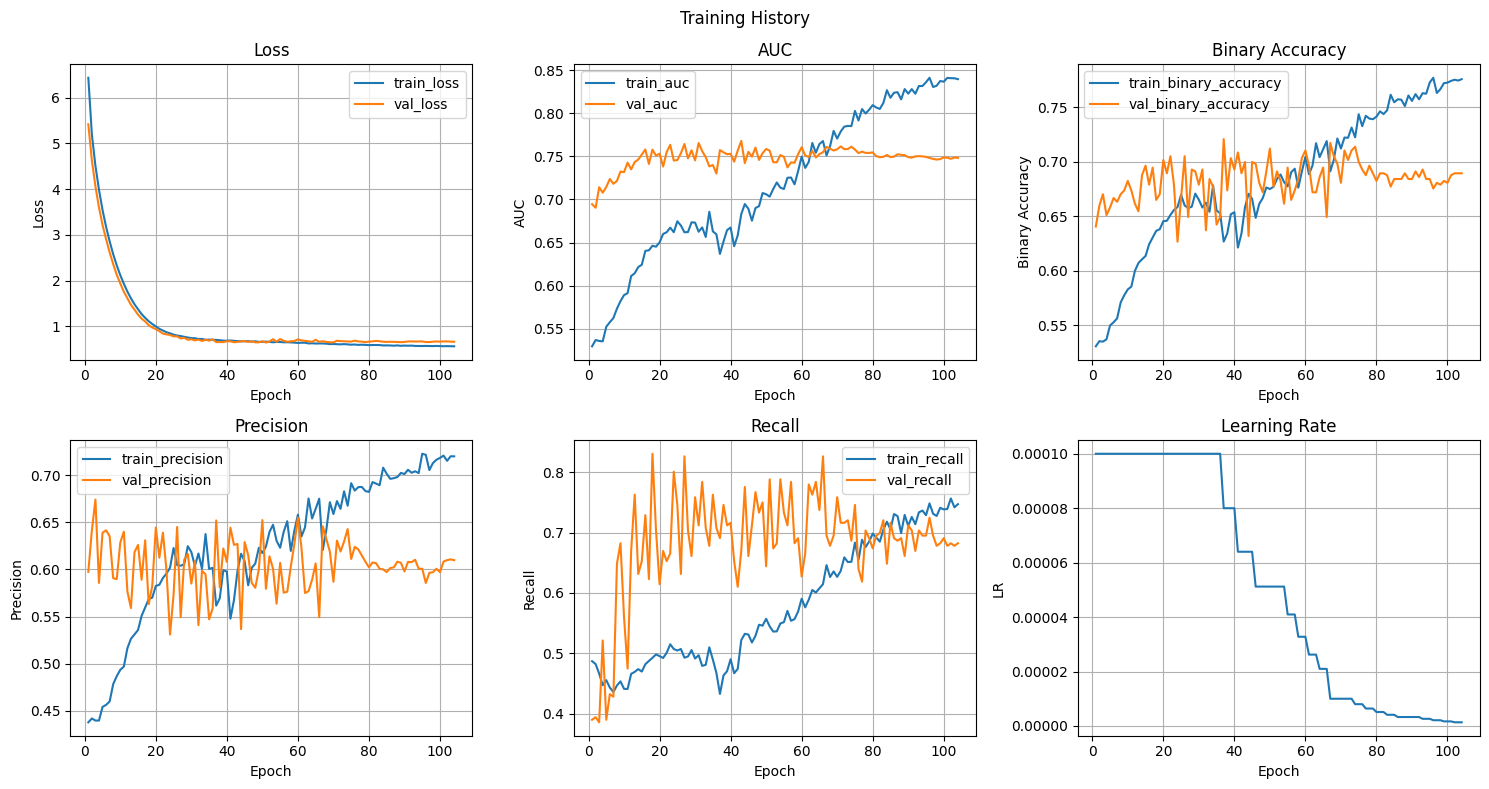

In [15]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [ ]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_resnet50v2_image_random.csv'

#### Split by Patient ID

In [17]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [18]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [20]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("resnet50v2")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [21]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
316/316 [==============================] - 19s 49ms/step - loss: 6.4702 - auc_1: 0.5244 - binary_accuracy: 0.5241 - precision_1: 0.4227 - recall_1: 0.4845 - val_loss: 5.4500 - val_auc_1: 0.6889 - val_binary_accuracy: 0.6362 - val_precision_1: 0.5388 - val_recall_1: 0.5566 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 14s 39ms/step - loss: 5.2300 - auc_1: 0.5254 - binary_accuracy: 0.5273 - precision_1: 0.4231 - recall_1: 0.4652 - val_loss: 4.6378 - val_auc_1: 0.6996 - val_binary_accuracy: 0.6437 - val_precision_1: 0.5436 - val_recall_1: 0.6179 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 14s 39ms/step - loss: 4.5285 - auc_1: 0.5354 - binary_accuracy: 0.5357 - precision_1: 0.4300 - recall_1: 0.4557 - val_loss: 4.0704 - val_auc_1: 0.7099 - val_binary_accuracy: 0.6642 - val_precision_1: 0.6194 - val_recall_1: 0.3915 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 14s 40ms/step - loss: 4.0057 - auc_1: 0.533

In [22]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
316/316 [==============================] - 13s 37ms/step - loss: 0.6406 - auc_1: 0.7232 - binary_accuracy: 0.6732 - precision_1: 0.6017 - recall_1: 0.5671 - val_loss: 0.6537 - val_auc_1: 0.7301 - val_binary_accuracy: 0.6791 - val_precision_1: 0.6136 - val_recall_1: 0.5094 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 15s 39ms/step - loss: 0.6361 - auc_1: 0.7368 - binary_accuracy: 0.6904 - precision_1: 0.6366 - recall_1: 0.5454 - val_loss: 0.6355 - val_auc_1: 0.7266 - val_binary_accuracy: 0.6791 - val_precision_1: 0.6205 - val_recall_1: 0.4858 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 15s 41ms/step - loss: 0.6229 - auc_1: 0.7568 - binary_accuracy: 0.7064 - precision_1: 0.6655 - recall_1: 0.5507 - val_loss: 0.6513 - val_auc_1: 0.7320 - val_binary_accuracy: 0.6866 - val_precision_1: 0.6410 - val_recall_1: 0.4717 - lr: 1.0000e-05
Epoch 4/80
316/316 [==============================] - 14s 39ms/step - loss: 0.6283 - auc_1: 0.747

In [23]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
316/316 [==============================] - 13s 37ms/step - loss: 0.5976 - auc_1: 0.7980 - binary_accuracy: 0.7400 - precision_1: 0.6898 - recall_1: 0.6486 - val_loss: 0.6527 - val_auc_1: 0.7212 - val_binary_accuracy: 0.6772 - val_precision_1: 0.6309 - val_recall_1: 0.4434 - lr: 3.2768e-06
Epoch 2/80
316/316 [==============================] - 14s 36ms/step - loss: 0.5942 - auc_1: 0.8082 - binary_accuracy: 0.7483 - precision_1: 0.7035 - recall_1: 0.6523 - val_loss: 0.6468 - val_auc_1: 0.7242 - val_binary_accuracy: 0.6754 - val_precision_1: 0.6145 - val_recall_1: 0.4811 - lr: 3.2768e-06
Epoch 3/80
316/316 [==============================] - 15s 41ms/step - loss: 0.6015 - auc_1: 0.8039 - binary_accuracy: 0.7508 - precision_1: 0.7024 - recall_1: 0.6657 - val_loss: 0.6532 - val_auc_1: 0.7239 - val_binary_accuracy: 0.6810 - val_precision_1: 0.6306 - val_recall_1: 0.4670 - lr: 3.2768e-06
Epoch 4/80
316/316 [==============================] - 14s 40ms/step - loss: 0.5898 - auc_1: 0.807

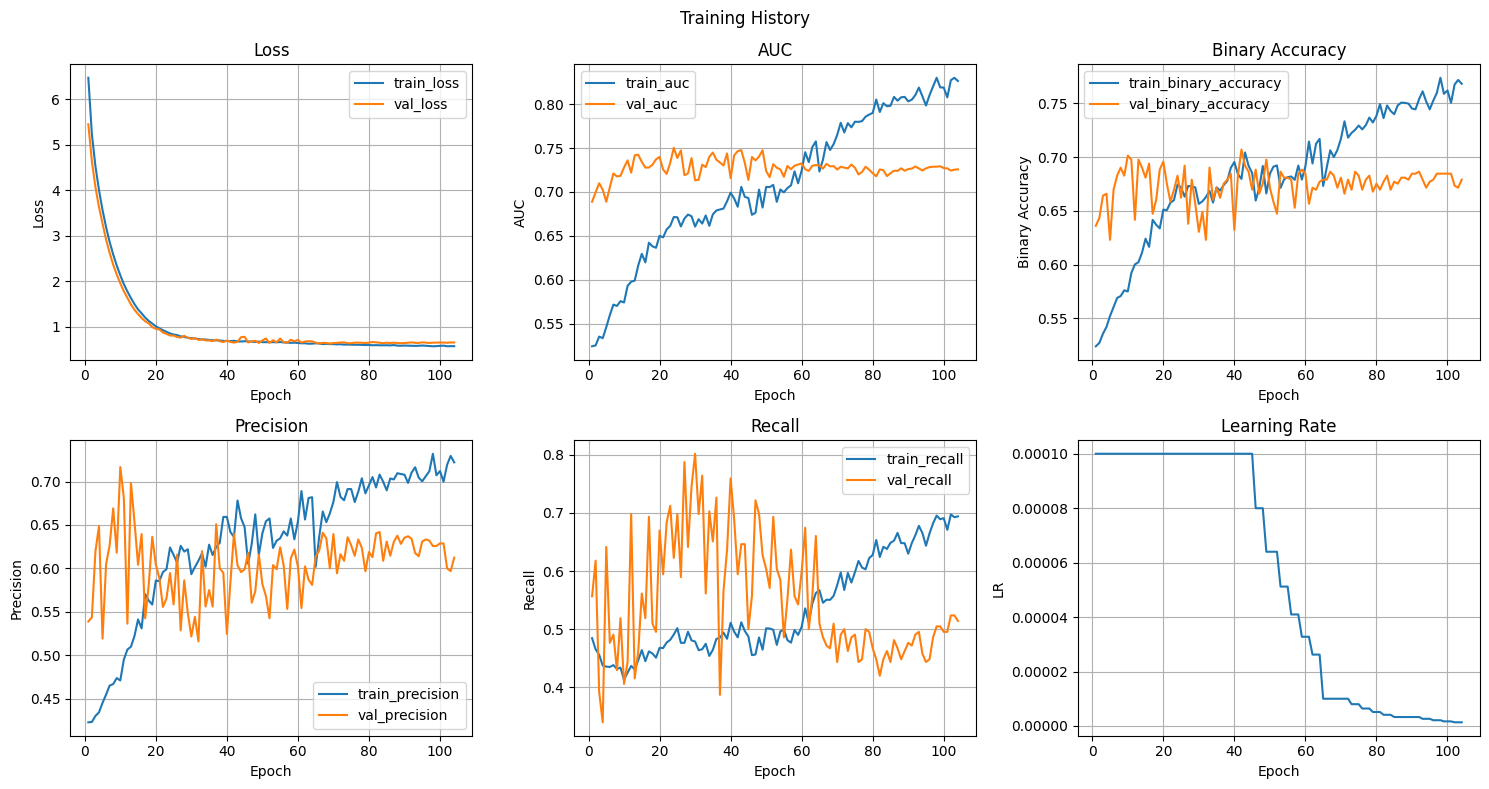

In [24]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [26]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_resnet50v2_patient_random.csv'

## FINAL TRAINING

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [10]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [ ]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=70, # when model start to overfit during experiments
)

Epoch 1/70


2025-09-21 12:31:33.510790: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 12:31:33.632550: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 12:31:33.640704: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 12:31:33.640769: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 12:31:33.646749: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 12:31:33.646906: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 12:31:33.695319: I tensorflow/stream_executor/cuda/c

403/403 [==============================] - 25s 48ms/step - loss: 6.2900 - auc: 0.5547 - binary_accuracy: 0.5448 - precision: 0.4544 - recall: 0.5171 - lr: 1.0000e-04
Epoch 2/70
403/403 [==============================] - 20s 49ms/step - loss: 4.9721 - auc: 0.5640 - binary_accuracy: 0.5511 - precision: 0.4588 - recall: 0.4939 - lr: 1.0000e-04
Epoch 3/70
403/403 [==============================] - 21s 52ms/step - loss: 4.2363 - auc: 0.5712 - binary_accuracy: 0.5585 - precision: 0.4660 - recall: 0.4843 - lr: 1.0000e-04
Epoch 4/70
403/403 [==============================] - 21s 51ms/step - loss: 3.6587 - auc: 0.5900 - binary_accuracy: 0.5747 - precision: 0.4844 - recall: 0.4891 - lr: 1.0000e-04
Epoch 5/70
403/403 [==============================] - 21s 51ms/step - loss: 3.1899 - auc: 0.6023 - binary_accuracy: 0.5810 - precision: 0.4918 - recall: 0.4858 - lr: 1.0000e-04
Epoch 6/70
403/403 [==============================] - 21s 52ms/step - loss: 2.7969 - auc: 0.6176 - binary_accuracy: 0.5939 - p

In [12]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_image_random.h5")

In [13]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/full_pretrained_resnet50v2_image_random.csv'

In [14]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [15]:
# Final evaluation
model.evaluate(ds_test_image_random)

11/11 [==============================] - 1s 44ms/step - loss: 0.6827 - auc: 0.7319 - binary_accuracy: 0.6420 - precision: 0.5316 - recall: 0.7319   


[0.6827343106269836,
 0.7319475412368774,
 0.6420454382896423,
 0.5315789580345154,
 0.7318840622901917]

#### Split by Patient ID

In [16]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [17]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [18]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=75, # when model start to overfit during experiments
)

Epoch 1/75


392/392 [==============================] - 24s 49ms/step - loss: 6.3076 - auc_1: 0.5554 - binary_accuracy: 0.5450 - precision_1: 0.4435 - recall_1: 0.5112 - lr: 1.0000e-04
Epoch 2/75
392/392 [==============================] - 20s 51ms/step - loss: 5.0069 - auc_1: 0.5603 - binary_accuracy: 0.5514 - precision_1: 0.4478 - recall_1: 0.4897 - lr: 1.0000e-04
Epoch 3/75
392/392 [==============================] - 20s 51ms/step - loss: 4.2706 - auc_1: 0.5729 - binary_accuracy: 0.5619 - precision_1: 0.4579 - recall_1: 0.4795 - lr: 1.0000e-04
Epoch 4/75
392/392 [==============================] - 21s 52ms/step - loss: 3.7220 - auc_1: 0.5767 - binary_accuracy: 0.5657 - precision_1: 0.4610 - recall_1: 0.4644 - lr: 1.0000e-04
Epoch 5/75
392/392 [==============================] - 20s 51ms/step - loss: 3.2646 - auc_1: 0.5917 - binary_accuracy: 0.5748 - precision_1: 0.4715 - recall_1: 0.4638 - lr: 1.0000e-04
Epoch 6/75
392/392 [==============================] - 21s 52ms/step - loss: 2.8805 - auc_1: 0.59

In [19]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_patient_random.h5")

In [20]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/full_pretrained_resnet50v2_patient_random.csv'

In [21]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [22]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 1s 34ms/step - loss: 0.8243 - auc_1: 0.7587 - binary_accuracy: 0.6794 - precision_1: 0.6019 - recall_1: 0.7448 


[0.8242857456207275,
 0.7586889863014221,
 0.6793892979621887,
 0.6019184589385986,
 0.7448071241378784]